Available COHP labels:
['average', '1']


<Figure size 1000x600 with 0 Axes>

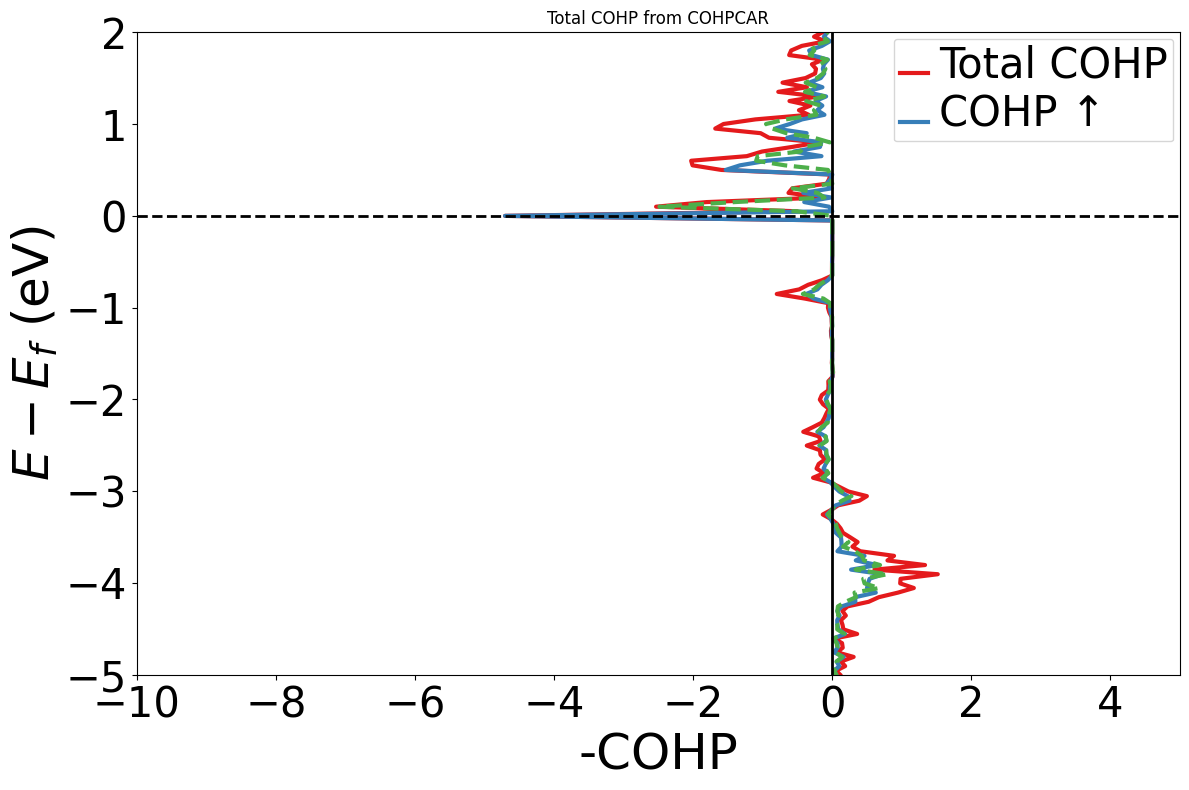

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from pymatgen.io.lobster import Cohpcar
from pymatgen.electronic_structure.cohp import Cohp
from pymatgen.electronic_structure.core import Spin
from pymatgen.electronic_structure.plotter import CohpPlotter
from tkinter import Tk, filedialog

workdir = Path(".")
cohp_file = workdir / "COHPCAR.LCFO.lobster"
structure_file = workdir / "CONTCAR"

cohpcar = Cohpcar(filename=cohp_file, is_lcfo=True)
labels = list(cohpcar.cohp_data.keys())
print("Available COHP labels:")
print(labels[:20])

raw = cohpcar.cohp_data["1"]

energies = cohpcar.energies
ef = 0.0

# spin-up COHP
cohp_up = Cohp(
    efermi=ef,
    energies=energies,
    cohp={Spin.up: raw["COHP"][Spin.up]},
    are_coops=False,
)

# spin-down COHP
cohp_down = Cohp(
    efermi=ef,
    energies=energies,
    cohp={Spin.down: raw["COHP"][Spin.down]},
    are_coops=False,
)

import numpy as np

total_cohp = raw["COHP"][Spin.up] + raw["COHP"][Spin.down]

cohp_total = Cohp(
    efermi=ef,
    energies=energies,
    cohp={Spin.up: total_cohp},
    are_coops=False,
)

plt.figure(figsize=(10, 6))

cohp_plotter = CohpPlotter(zero_at_efermi=True, are_coops=False)
cohp_plotter.add_cohp("Total COHP", cohp_total)
cohp_plotter.add_cohp("COHP ↑", cohp_up)
cohp_plotter.add_cohp("COHP ↓", cohp_down)

cohp_plotter.get_plot(xlim=(-10, 5), ylim=(-5, 2))
plt.title("Total COHP from COHPCAR")
plt.tight_layout()
plt.show()


available keys (first 20): ['average', '1']


AttributeError: 'Axes' object has no attribute 'gca'

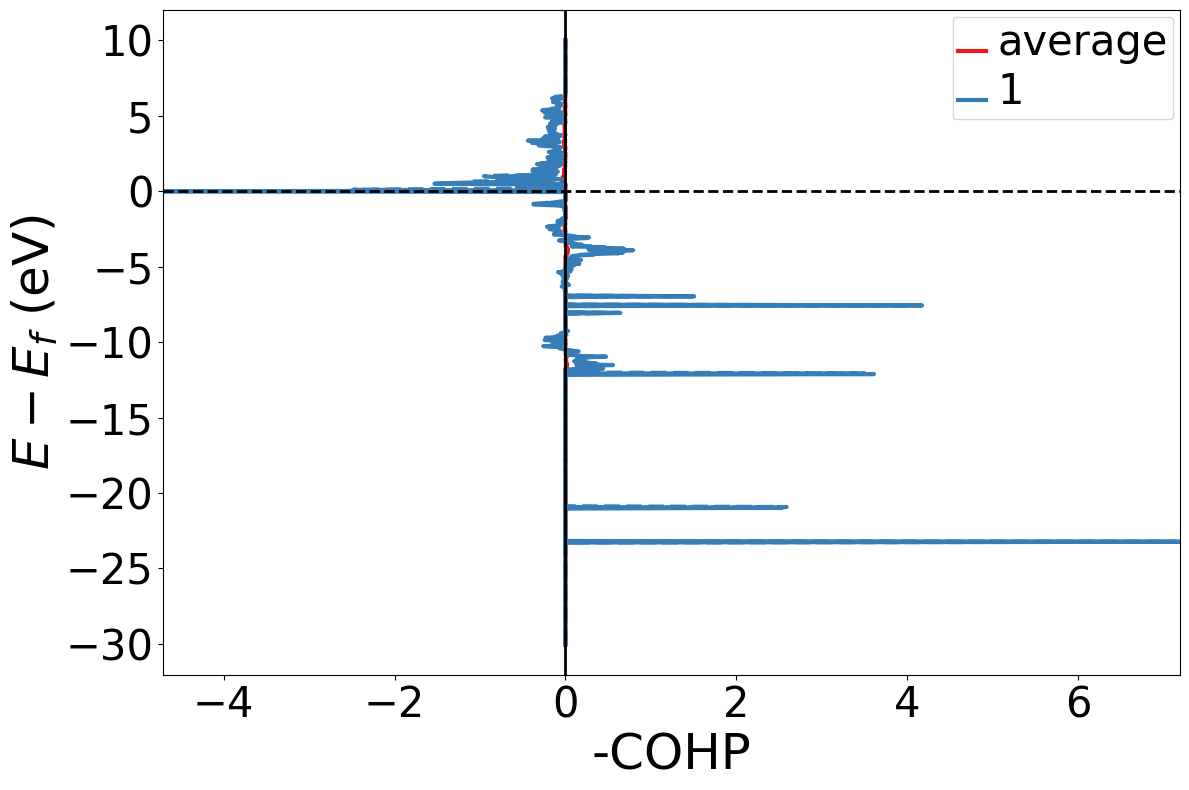

In [8]:
import matplotlib.pyplot as plt

from pymatgen.io.lobster import Cohpcar
from pymatgen.electronic_structure.cohp import Cohp
from pymatgen.electronic_structure.plotter import CohpPlotter

cohpcar = Cohpcar(filename="COHPCAR.LCFO.lobster", is_lcfo=True)

# COHP dict -> Cohp 객체로 변환 (matgenb 예제 패턴)
cdata = cohpcar.cohp_data
cdata_processed = {}
for key, c in cdata.items():
    c = dict(c)  # 원본 보호
    c["efermi"] = 0.0                 # LOBSTER COHP 에너지는 보통 Ef=0으로 shift됨(예제 관례)
    c["energies"] = cohpcar.energies
    c["are_coops"] = False
    cdata_processed[key] = Cohp.from_dict(c)

print("available keys (first 20):", list(cdata_processed.keys())[:20])

cp = CohpPlotter()
# 전체 다 올리면 너무 많을 수 있어요. 우선 일부만:
some_keys = list(cdata_processed.keys())[:5]
cp.add_cohp_dict({k: cdata_processed[k] for k in some_keys})

fig = cp.get_plot(integrated=False)
ax = fig.gca()
ax.axvline(0, linestyle="--", linewidth=1)   # Ef=0 표시
plt.show()


Loaded 2 labels from COHPCAR.LCFO.lobster
First 30 labels: ['average', '1']


<Figure size 300x400 with 0 Axes>

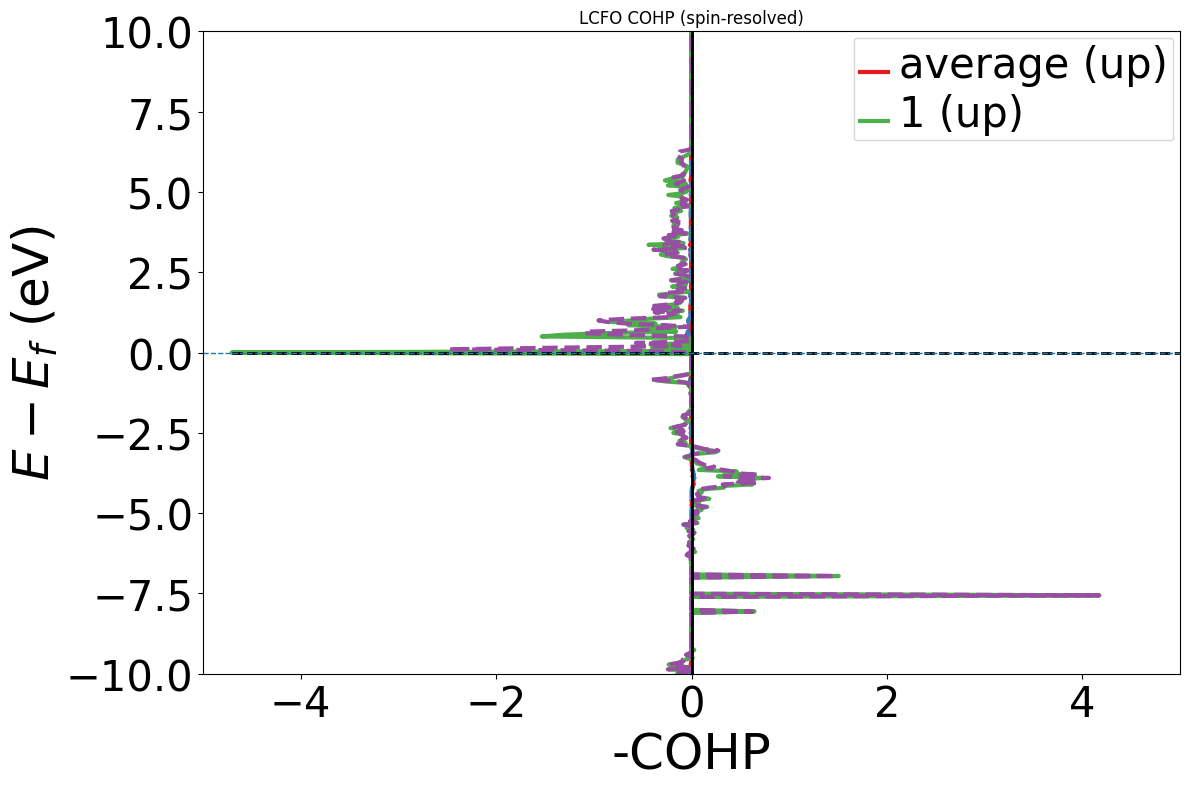

In [ ]:
import matplotlib.pyplot as plt
from pymatgen.io.lobster import Cohpcar
from pymatgen.electronic_structure.cohp import Cohp
from pymatgen.electronic_structure.plotter import CohpPlotter
from pymatgen.electronic_structure.core import Spin

def load_lcfo_cohps(cohpcar_path: str):
    cohpcar = Cohpcar(filename=str(cohpcar_path), is_lcfo=True)
    raw = cohpcar.cohp_data
    energies = cohpcar.energies

    cohp_objs = {}
    for label, d in raw.items():
        dd = dict(d)
        dd["energies"] = energies
        dd.setdefault("efermi", 0.0)
        dd.setdefault("are_coops", False)
        cohp_objs[label] = Cohp.from_dict(dd)

    return cohpcar, cohp_objs

# ========= 사용자 설정 =========
COHPCAR_FILE = "COHPCAR.LCFO.lobster"
TARGET_LABELS = None   # 예: ["1", "2"] / None이면 자동
N_AUTO = 5

XLIM = (-5, 5)
YLIM = (-10, 10)
FIGSIZE = (3, 4)

PLOT_INTEGRATED = False   # True면 ICOHP(E)로
INVERT_AXES = True
PLOT_NEGATIVE = True
# ============================

cohpcar, cohp_objs = load_lcfo_cohps(COHPCAR_FILE)

labels = list(cohp_objs.keys())
print(f"Loaded {len(labels)} labels from {COHPCAR_FILE}")
print("First 30 labels:", labels[:30])

if TARGET_LABELS is None:
    TARGET_LABELS = labels[:min(N_AUTO, len(labels))]

plt.figure(figsize=FIGSIZE)

cp = CohpPlotter(zero_at_efermi=True)

for lb in TARGET_LABELS:
    if lb not in cohp_objs:
        raise KeyError(f"Label '{lb}' not found. Example labels: {labels[:20]}")

    base = cohp_objs[lb]

    # integrated=True일 때는 ICOHP(E)를 그리고 싶을 수 있는데,
    # CohpPlotter.get_plot(integrated=True)가 알아서 icohp를 사용합니다.
    # 여기서는 Cohp 객체를 spin별로 나눈 것만 add 하면 됩니다.
    up, down = split_spin_cohp(base)

    # spin이 없는(non-magnetic) 경우: 그냥 원본 한 번만 추가
    if up is None and down is None:
        cp.add_cohp(f"{lb}", base)
    else:
        if up is not None:
            cp.add_cohp(f"{lb} (up)", up)
        if down is not None:
            cp.add_cohp(f"{lb} (down)", down)

ax = cp.get_plot(
    integrated=PLOT_INTEGRATED,
    invert_axes=INVERT_AXES,
    plot_negative=PLOT_NEGATIVE,
)

if XLIM is not None:
    ax.set_xlim(*XLIM)
if YLIM is not None:
    ax.set_ylim(*YLIM)

if INVERT_AXES:
    ax.axhline(0, linestyle="--", linewidth=1)
else:
    ax.axvline(0, linestyle="--", linewidth=1)

ax.set_title("LCFO COHP (spin-resolved)" if not PLOT_INTEGRATED else "LCFO ICOHP(E) (spin-resolved)")
plt.tight_layout()
plt.show()
